[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ELTE-DSED/Intro-Data-Security/blob/main/module_06_confidentiality_attacks/Lab_6b_Model_Inversion_Attacks_and_Defenses.ipynb)

# Lab 6b: Model Inversion Attacks and Defenses
---

## Learning Objectives

By the end of this lab, you will understand:

1. **Model Inversion:** Reconstructing training data from model parameters/outputs
2. **Privacy Extraction:** How gradients leak information about training samples
3. **Attack Vectors:** Feature inversion, sample reconstruction, attribute inference
4. **Defense Mechanisms:** Differential privacy, gradient clipping, output perturbation
5. **Threat Model:** White-box vs black-box inversion attacks
6. **Real-World Impact:** Reconstructing faces, names, sensitive attributes from ML models

## Table of Contents

1. [Threat Model: Data Reconstruction](#threat-model)
2. [Feature Inversion: Basic Attack](#feature-inversion)
3. [Gradient-Based Sample Reconstruction](#gradient-reconstruction)
4. [Attribute Inference Attack](#attribute-inference)
5. [Defense Mechanisms](#defenses)
6. [Defense Effectiveness Analysis](#effectiveness)
7. [Exercises](#exercises)

## Threat Model: Data Reconstruction <a id="threat-model"></a>

- Can an attacker reconstruct training data from model outputs/parameters?

### Real-World Scenarios:

| Scenario | Attack | Data at Risk | Impact |
|----------|--------|--------------|--------|
| **Face Recognition** | Reconstruct faces | Biometric data | Identity theft |
| **Medical Records** | Reconstruct medical history | Patient data | Privacy violation |
| **Credit Scoring** | Infer financial attributes | Income/credit data | Discriminatory use |

### Why it leaks data:

1. **Model Capacity:** Bigger models usually remember more detail.
2. **Training Data Uniqueness:** Rare or unusual samples are easier to recover.
3. **Confidence Signals:** High-confidence outputs often reveal what the model has memorized.

## Model Inversion Theory <a id="theory"></a>

A trained model can leak visual clues about its training data when an attacker asks the right questions.

### Three visual attack styles:

- **Feature inversion:** start from noise and optimize until the image or feature vector looks like a target class.
- **Gradient inversion:** rebuild an input that explains the gradients seen during training.
- **Attribute inference:** predict a hidden property such as brightness, age, or gender from model behavior.

### Why it matters:

These attacks may not recover the exact original sample, but they can still reveal recognizable structure and sensitive attributes.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List
from PIL import Image
from dataclasses import dataclass
import torch.nn.functional as F
from sklearn.datasets import load_breast_cancer, fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## Gradient Ascent Reconstruction on Faces

Try to compare the average face for each subject with a reconstruction obtained by gradient ascent.

In [5]:
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X_faces = faces.data
y_faces = faces.target

N_SUBJECTS = 10
subject_mask = y_faces < N_SUBJECTS
X_faces = X_faces[subject_mask]
y_faces = y_faces[subject_mask]

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
    X_faces, y_faces, test_size=0.2, random_state=42, stratify=y_faces
)

In [6]:
class FaceNet(nn.Module):
    def __init__(self, in_dim=4096, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
Xt = torch.tensor(Xf_tr, dtype=torch.float32, device=device)
yt = torch.tensor(yf_tr, dtype=torch.long, device=device)
Xv = torch.tensor(Xf_te, dtype=torch.float32, device=device)
yv = torch.tensor(yf_te, dtype=torch.long, device=device)

face_model = FaceNet(n_classes=N_SUBJECTS).to(device)
face_optimizer = optim.Adam(face_model.parameters(), lr=1e-3, weight_decay=1e-4)
face_criterion = nn.CrossEntropyLoss()

EPOCHS = 80
for epoch in range(EPOCHS):
    face_model.train()
    face_optimizer.zero_grad()
    face_loss = face_criterion(face_model(Xt), yt)
    face_loss.backward()
    face_optimizer.step()
    if epoch % 10 == 0:
        print(f'Epoch {epoch:2d}/{EPOCHS} - loss: {face_loss.item():.4f}')

face_model.eval()
with torch.no_grad():
    tr_acc = (face_model(Xt).argmax(1) == yt).float().mean().item()
    te_acc = (face_model(Xv).argmax(1) == yv).float().mean().item()
print(f'Face model — Train acc: {tr_acc:.3f}, Test acc: {te_acc:.3f}')

Epoch  0/80 - loss: 2.3072
Epoch 10/80 - loss: 1.9652
Epoch 20/80 - loss: 1.2090
Epoch 30/80 - loss: 0.6987
Epoch 40/80 - loss: 0.3085
Epoch 50/80 - loss: 0.1465
Epoch 60/80 - loss: 0.0823
Epoch 70/80 - loss: 0.0482
Face model — Train acc: 1.000, Test acc: 0.950


In [8]:
def invert_image(model, target_class, n_iter=2000, lr=0.01, tv_weight=1e-4, l2_weight=1e-3):
    model.eval()
    x = torch.rand(1, 4096, requires_grad=True, device=device)
    opt = optim.Adam([x], lr=lr)
    for i in range(n_iter):
        opt.zero_grad()
        logits = model(x)
        loss_cls = -logits[0, target_class]
        loss_l2 = l2_weight * (x ** 2).sum()
        img = x.view(1, 64, 64)
        tv = ((img[:, 1:, :] - img[:, :-1, :]) ** 2).sum() + ((img[:, :, 1:] - img[:, :, :-1]) ** 2).sum()
        loss_tv = tv_weight * tv
        loss = loss_cls + loss_l2 + loss_tv
        loss.backward()
        opt.step()
        with torch.no_grad():
            x.clamp_(0, 1)
        if (i + 1) % 500 == 0:
            print(f'  Iteration {i + 1}/{n_iter} — confidence={torch.softmax(logits, dim=1)[0, target_class].item():.4f}')
    return x.detach().cpu().numpy().reshape(64, 64)

In [9]:
TARGET_SUBJECTS = [0, 1, 2, 3]
print('Running gradient-ascent inversion...')
inverted_faces = {s: invert_image(face_model, s) for s in TARGET_SUBJECTS}
print('Done.')

Running gradient-ascent inversion...
  Iteration 500/2000 — confidence=1.0000
  Iteration 1000/2000 — confidence=1.0000
  Iteration 1500/2000 — confidence=1.0000
  Iteration 2000/2000 — confidence=1.0000
  Iteration 500/2000 — confidence=1.0000
  Iteration 1000/2000 — confidence=1.0000
  Iteration 1500/2000 — confidence=1.0000
  Iteration 2000/2000 — confidence=1.0000
  Iteration 500/2000 — confidence=1.0000
  Iteration 1000/2000 — confidence=1.0000
  Iteration 1500/2000 — confidence=1.0000
  Iteration 2000/2000 — confidence=1.0000
  Iteration 500/2000 — confidence=0.9995
  Iteration 1000/2000 — confidence=0.9994
  Iteration 1500/2000 — confidence=0.9994
  Iteration 2000/2000 — confidence=0.9994
Done.


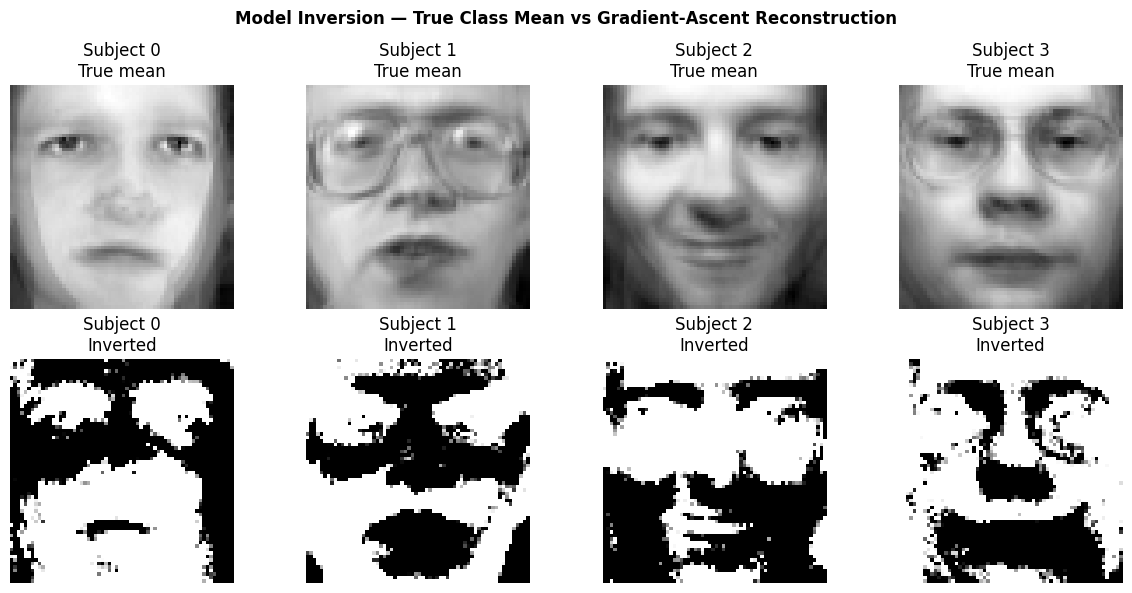

In [10]:


fig, axes = plt.subplots(2, len(TARGET_SUBJECTS), figsize=(3 * len(TARGET_SUBJECTS), 6))

for col, subj in enumerate(TARGET_SUBJECTS):
    true_mean_face = Xf_tr[yf_tr == subj].mean(axis=0).reshape(64, 64)
    axes[0, col].imshow(true_mean_face, cmap='gray')
    axes[0, col].set_title(f'Subject {subj}\nTrue mean')
    axes[0, col].axis('off')

    axes[1, col].imshow(inverted_faces[subj], cmap='gray')
    axes[1, col].set_title(f'Subject {subj}\nInverted')
    axes[1, col].axis('off')

plt.suptitle('Model Inversion — True Class Mean vs Gradient-Ascent Reconstruction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Inversion on Tabular Data

We will try to show how a model can be pushed toward a target class from random noise, and how the recovered feature vector compares with the average sample from that class.

In [11]:
bc = load_breast_cancer()
X_bc = bc.data.astype(np.float32)
y_bc = bc.target.astype(np.int64)

X_bc_train_raw, X_bc_test_raw, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=42, stratify=y_bc
)
bc_scaler = StandardScaler()
X_bc_train = bc_scaler.fit_transform(X_bc_train_raw).astype(np.float32)
X_bc_test = bc_scaler.transform(X_bc_test_raw).astype(np.float32)

X_bc_train_t = torch.tensor(X_bc_train, dtype=torch.float32, device=device)
y_bc_train_t = torch.tensor(y_bc_train, dtype=torch.long, device=device)

In [12]:
class TabularInversionNet(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
tabular_model = TabularInversionNet(X_bc_train.shape[1]).to(device)
tabular_optimizer = optim.Adam(tabular_model.parameters(), lr=0.01)
tabular_criterion = nn.CrossEntropyLoss()

for epoch in range(300):
    tabular_model.train()
    tabular_optimizer.zero_grad()
    tabular_loss = tabular_criterion(tabular_model(X_bc_train_t), y_bc_train_t)
    tabular_loss.backward()
    tabular_optimizer.step()
    if (epoch + 1) % 100 == 0:
        with torch.no_grad():
            tabular_train_acc = (tabular_model(X_bc_train_t).argmax(1) == y_bc_train_t).float().mean().item()
        print(f'Epoch {epoch + 1:3d}/300 - loss={tabular_loss.item():.4f}, train acc={tabular_train_acc:.3f}')

Epoch 100/300 - loss=0.0008, train acc=1.000
Epoch 200/300 - loss=0.0001, train acc=1.000
Epoch 300/300 - loss=0.0000, train acc=1.000


In [14]:
def invert_feature_vector(model: nn.Module, target_class: int, n_features: int, steps: int = 1200, lr: float = 0.05, l2_weight: float = 0.01):
    model.eval()
    x = torch.randn(1, n_features, device=device, requires_grad=True)
    optimizer = optim.Adam([x], lr=lr)
    for _ in range(steps):
        optimizer.zero_grad()
        logits = model(x)
        class_loss = -logits[0, target_class]
        reg_loss = l2_weight * (x ** 2).mean()
        loss = class_loss + reg_loss
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            x.clamp_(-3, 3)
    return x.detach().cpu().numpy().squeeze()

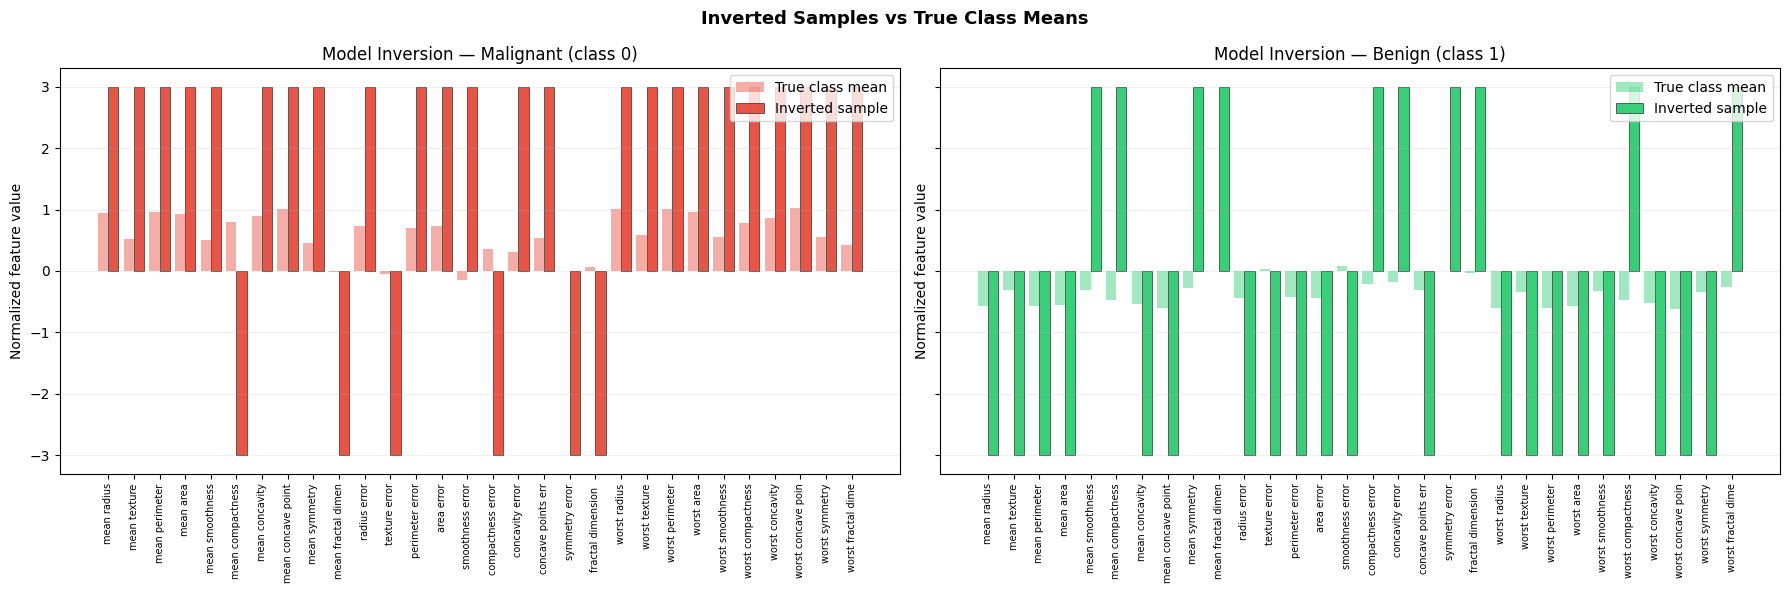

In [15]:
malignant_mean = X_bc_train[y_bc_train == 0].mean(axis=0)
benign_mean = X_bc_train[y_bc_train == 1].mean(axis=0)
inverted_malignant = invert_feature_vector(tabular_model, 0, X_bc_train.shape[1])
inverted_benign = invert_feature_vector(tabular_model, 1, X_bc_train.shape[1])

feature_names = [name[:18] for name in bc.feature_names]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, class_name, true_mean, inv_sample, color in [
    (axes[0], 'Malignant (class 0)', malignant_mean, inverted_malignant, '#e74c3c'),
    (axes[1], 'Benign (class 1)', benign_mean, inverted_benign, '#2ecc71'),
]:
    idx = np.arange(len(feature_names))
    ax.bar(idx - 0.2, true_mean, 0.4, label='True class mean', color=color, alpha=0.45)
    ax.bar(idx + 0.2, inv_sample, 0.4, label='Inverted sample', color=color, alpha=0.95, edgecolor='black', linewidth=0.4)
    ax.set_title(f'Model Inversion — {class_name}')
    ax.set_ylabel('Normalized feature value')
    ax.set_xticks(idx)
    ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Inverted Samples vs True Class Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Summary: Model Inversion Attacks and Defenses

1. **Feature Inversion:** Can reconstruct plausible images of target classes through gradient-based optimization

2. **Gradient-Based Reconstruction:** Can match gradients to recover training samples

3. **Attribute Inference:** Can predict sensitive attributes from model outputs

---

## Exercises

### Exercise 1: Feature Inversion Optimization
Improve feature inversion by:
- Varying TV weight (0.01, 0.1, 1.0)
- Adding frequency regularization (prefer low frequencies)
- Using different initialization (zero, Gaussian, real image perturbation)

Which combination produces most realistic images?

### Exercise 2: Gradient Inversion Attack
Implement full gradient inversion attack:
1. Use batch of real samples
2. Compute sum of gradients over batch
3. Reconstruct samples by matching batch gradient
4. Measure reconstruction quality (SSIM, perceptual distance)

How does batch size affect reconstruction difficulty?

### Exercise 3: Defense Evasion
Try to evade each defense:
- **Gradient Clipping:** Use batch attacks to amplify gradient signal
- **DP Noise:** Accumulate noise over multiple queries
- **Combined:** Design adaptive attack strategy

What defense combinations are most robust?

Which attributes are most vulnerable?

### Exercise 4: Defense Cost-Benefit Analysis
For production ML system:
- Model: Face recognition (high utility importance)
- Threat: Model inversion attacks
- Budget: 5% accuracy loss maximum

Design defense strategy that maximizes privacy within accuracy constraint.
Compare: Gradient clipping vs DP-SGD vs ensemble approaches